<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 50px;
  font-style: normal;
  background: linear-gradient(to right, rgba(0,32,68,0.15), rgba(253,124,7,0.15));
  letter-spacing: 3px;
  color: black;
  border-radius: 10px;
  text-align: center;
  line-height: 1.2;
  padding: 20px 10px;
">
📊 <span>Storytelling with</span><br>
<span style="color: #002044;">Introverts vs Extroverts:</span><br>
<span style="color: #fd7c07;"> A Data-Driven Journey</span>

</h1>


In [1]:
## https://www.kaggle.com/competitions/playground-series-s5e7

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import squarify
from pywaffle import Waffle
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.transforms import Bbox
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker
from matplotlib import font_manager
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("intro vs extro.csv")

In [4]:
test_df = pd.read_csv("test (1).csv")

In [5]:
test_df.shape

(6175, 8)

In [6]:
df.shape

(18524, 9)

In [7]:
df.isna().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

In [8]:
missing_cols = df.columns[df.isna().sum() > 0]
rows_with_missing = [set(df[df[col].isna()].index) for col in missing_cols]
common_missing = set.intersection(*rows_with_missing)
all_missing = set.union(*rows_with_missing)
print("Common missing rows count:", len(common_missing))
print("All missing rows count:", len(all_missing))
print("Perfect overlap?", len(common_missing) == len(all_missing))

Common missing rows count: 0
All missing rows count: 8335
Perfect overlap? False


In [9]:
extro = df[df["Personality"] == "Extrovert"]
intro = df[df["Personality"] == "Introvert"]
extro.shape,intro.shape

((13699, 9), (4825, 9))

In [10]:
# print("Extroverts missing values:")
print(extro.isna().sum())

print("\nIntroverts missing values:")
print(intro.isna().sum())


id                              0
Time_spent_Alone              909
Stage_fear                   1149
Social_event_attendance       732
Going_outside                 962
Drained_after_socializing     462
Friends_circle_size           700
Post_frequency                777
Personality                     0
dtype: int64

Introverts missing values:
id                             0
Time_spent_Alone             281
Stage_fear                   744
Social_event_attendance      448
Going_outside                504
Drained_after_socializing    687
Friends_circle_size          354
Post_frequency               487
Personality                    0
dtype: int64


In [11]:
num_cols = ["Time_spent_Alone", "Social_event_attendance", 
            "Going_outside", "Friends_circle_size", "Post_frequency"]

# Binary categorical columns
cat_cols = ["Stage_fear", "Drained_after_socializing"]

# Extroverts imputation
for col in num_cols:
    extro[col].fillna(extro[col].median(), inplace=True)
for col in cat_cols:
    extro[col].fillna(extro[col].mode()[0], inplace=True)

# Introverts imputation
for col in num_cols:
    intro[col].fillna(intro[col].median(), inplace=True)
for col in cat_cols:
    intro[col].fillna(intro[col].mode()[0], inplace=True)

# Recombine into one cleaned dataframe
df = pd.concat([extro, intro]).sort_index()

# Check if any missing left
print(df.isna().sum())


id                           0
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64


In [12]:
cols_to_convert = [
    "Time_spent_Alone",
    "Social_event_attendance",
    "Going_outside",
    "Friends_circle_size",
    "Post_frequency"
]
df[cols_to_convert] = df[cols_to_convert].astype("int64")


## `DATA VISUALIZATION`

In [13]:
cols = ['#002044', '#fd7c07', '#f4f2ef']
#       extrovert   introvert  facecolor
fonts = ["Americana XBdCn BT", 'Georgia', 'Times New Roman']

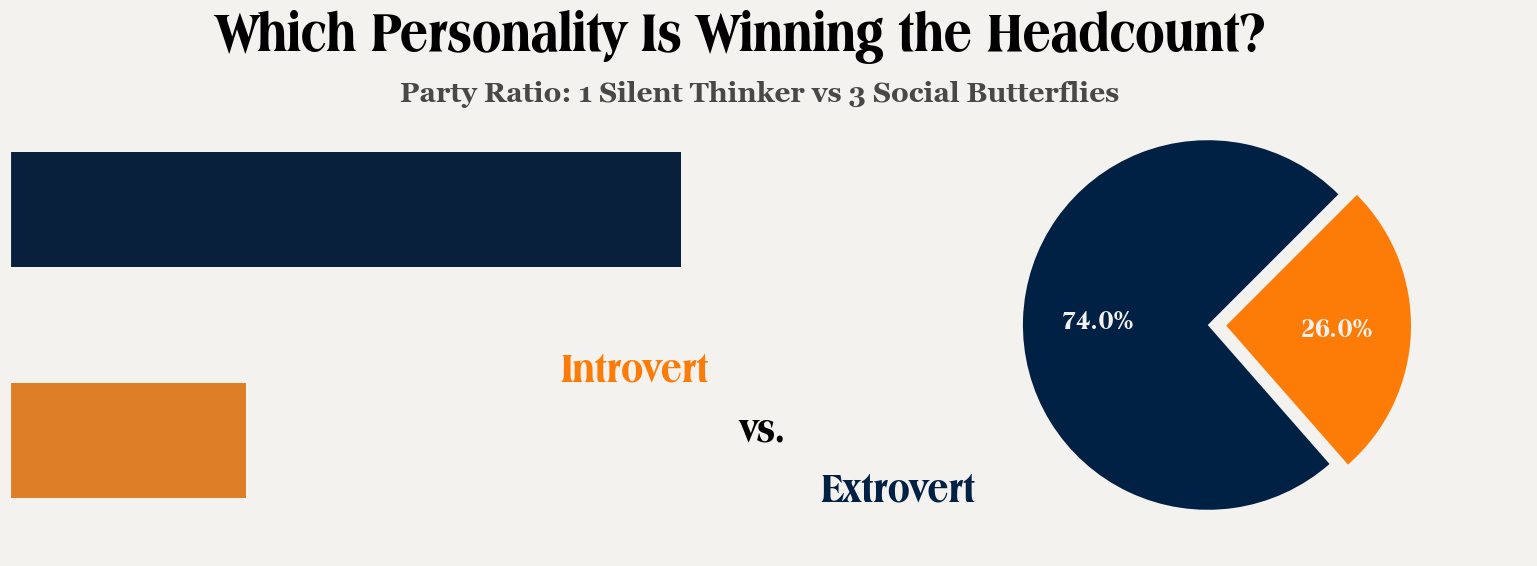

In [14]:
fig = plt.figure(figsize=(20, 6), dpi=100, facecolor=cols[2])
fig.patch.set_facecolor(cols[2])
fig.suptitle("Which Personality Is Winning the Headcount?", font="Americana XBdCn BT", fontsize=40, color='black', fontweight='bold', x=0.49, y=1.02,ha="center")
fig.text(0.5,0.88,"Party Ratio: 1 Silent Thinker vs 3 Social Butterflies",font=fonts[1], fontsize=20, color="black", fontweight="bold", ha="center", va="center",alpha=0.7)
ax1 = plt.subplot2grid((1, 2), (0, 0))
ax1.patch.set_facecolor(cols[2])
sns.countplot(y="Personality",data=df,width=0.5,palette=[cols[0], cols[1]],ax=ax1)
ax1.set_xlabel("");ax1.set_ylabel("");ax1.set_xticks([]);ax1.set_yticks([])

ax1.set_title("", color=cols[1], fontsize=14)

ax2 = plt.subplot2grid((1, 2), (0, 1))
ax2.set_facecolor(cols[2])
counts = df["Personality"].value_counts()
sizes = counts.values
labels = counts.index
explode = [0.1 if str(lbl).strip().lower() == "introvert" else 0 for lbl in labels]
ax2.pie(sizes,labels=labels,autopct='%1.1f%%',startangle=45,colors=[cols[0],cols[1]],explode=explode,
    textprops={'color': cols[2], 'fontsize': 20, 'weight': 'bold','fontfamily': fonts[0]})
ax2.set_xlabel("");ax2.set_ylabel("", color=cols[1])
for spine in ax1.spines.values():
    spine.set_color(cols[2])
fig.text(0.4,0.4,"Introvert",font= fonts[0],color=cols[1],fontsize=30,fontweight="bold")
fig.text(0.49,0.3,"vs.",font= fonts[0],color="black",fontsize=30,fontweight="bold")
fig.text(0.53,0.2,"Extrovert",font= fonts[0],color=cols[0],fontsize=30,fontweight="bold")
plt.show()


In [15]:
df_grouped = (df.groupby(["Drained_after_socializing", "Personality"]).size().reset_index(name="Count"))
df_grouped["Percentage"] = (df_grouped.groupby("Drained_after_socializing")["Count"].transform(lambda x: 100 * x / x.sum()))
df_grouped

,Drained_after_socializing,Personality,Count,Percentage
0,No,Extrovert,13463,97.735027
1,No,Introvert,312,2.264973
2,Yes,Extrovert,236,4.969467
3,Yes,Introvert,4513,95.030533


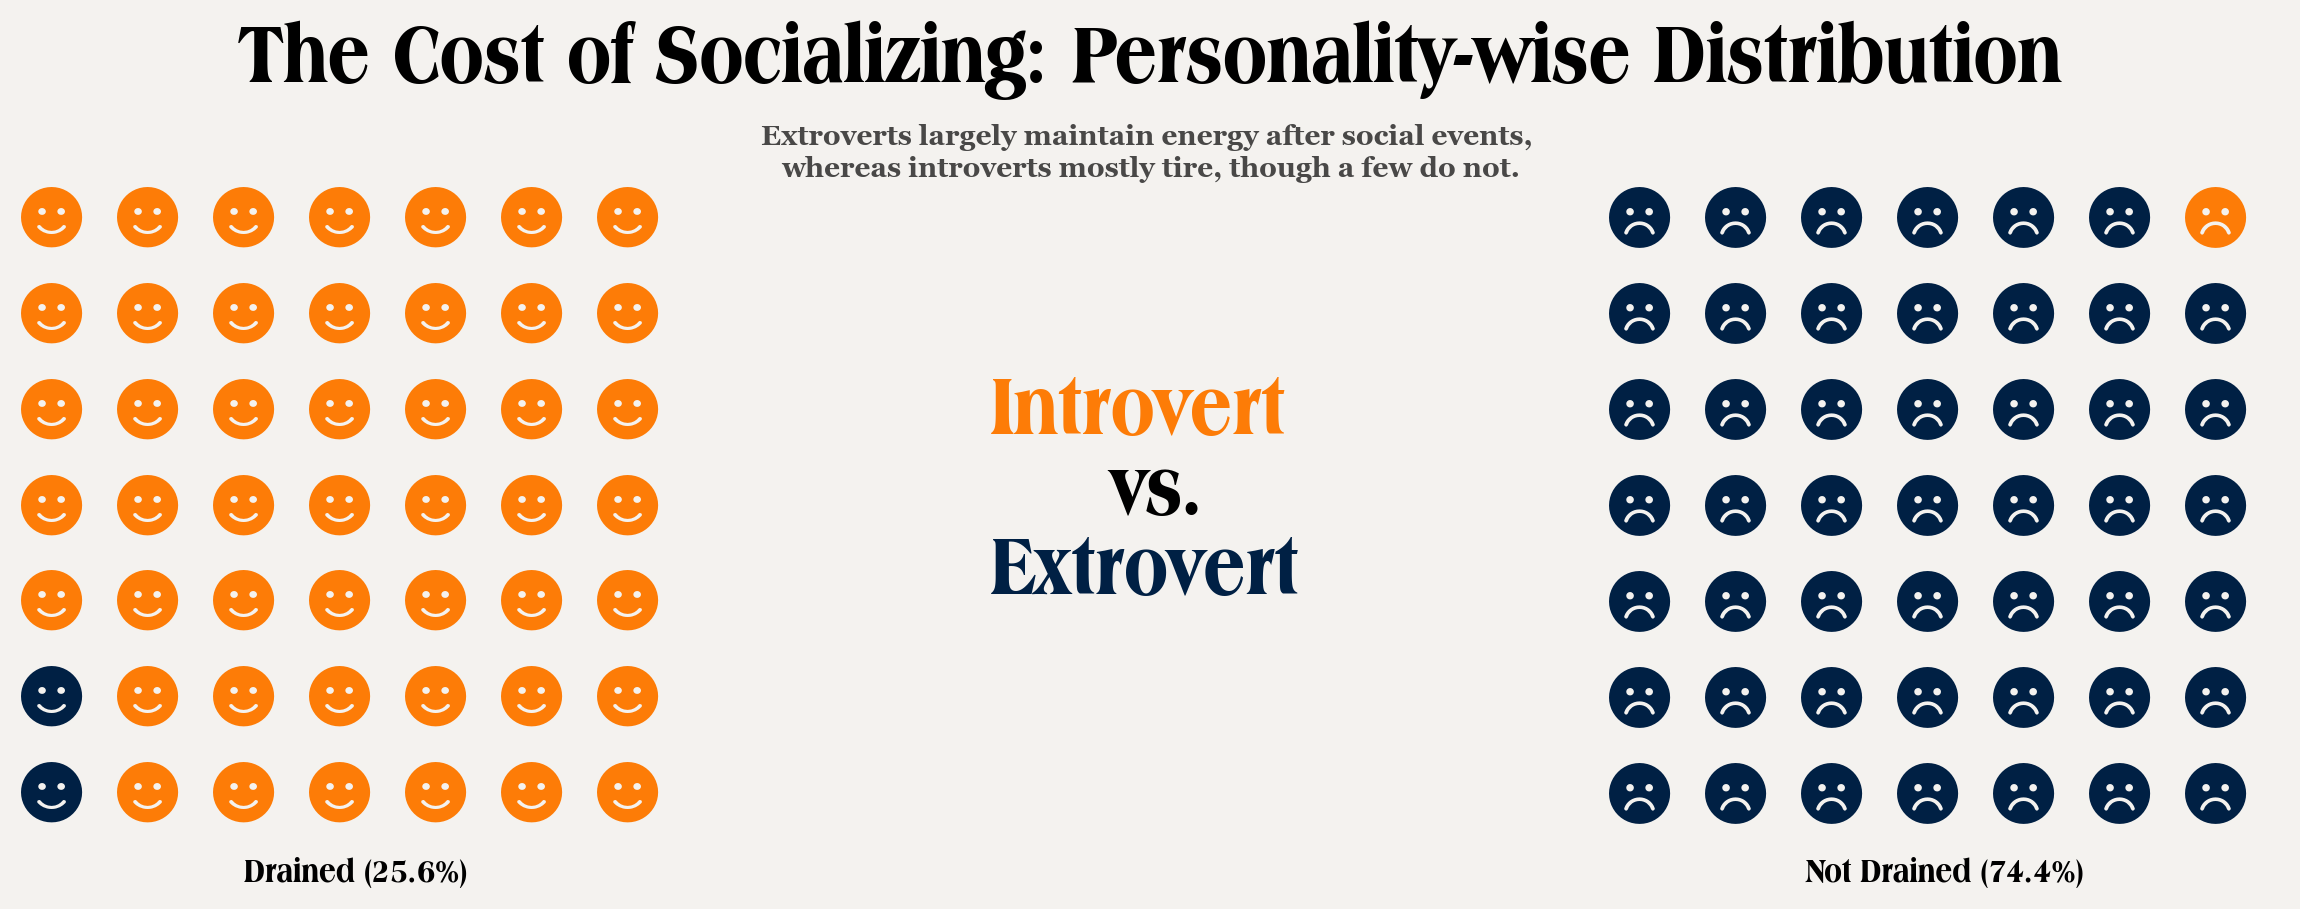

In [16]:
yes_extro = df_grouped.query("Drained_after_socializing == 'Yes' and Personality == 'Extrovert'")["Percentage"].values[0]
yes_intro = df_grouped.query("Drained_after_socializing == 'Yes' and Personality == 'Introvert'")["Percentage"].values[0]

no_extro = df_grouped.query("Drained_after_socializing == 'No' and Personality == 'Extrovert'")["Percentage"].values[0]
no_intro = df_grouped.query("Drained_after_socializing == 'No' and Personality == 'Introvert'")["Percentage"].values[0]

yes_per = round((df_grouped.query("Drained_after_socializing == 'Yes'")["Count"].sum() / len(df)) * 100, 1)
no_per = round((df_grouped.query("Drained_after_socializing == 'No'")["Count"].sum() / len(df)) * 100, 1)

# Waffle plots
plot1 = {'values': [yes_extro, yes_intro],'labels': ["Extrovert (Drained)", "Introvert (Drained)"],'icons': 'face-smile',   # Extrovert icon
    'colors': [cols[0], cols[1]],'icon_size': 22,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.0001,'plot_anchor': 'C','alpha': 0.9}

plot2 = {'values': [no_extro, no_intro],'labels': ["Extrovert (Not Drained)", "Introvert (Not Drained)"],'icons': 'frown',   # Introvert icon
    'colors': [cols[0], cols[1]],'icon_size': 22,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.0001,'plot_anchor': 'C','alpha': 0.9}

fig = plt.figure(FigureClass=Waffle,plots={121: plot1, 122: plot2},rows=7, columns=7,figsize=(20, 4), dpi=200)
fig.set_facecolor(cols[2])

fig.text(0.5, 1.04, "The Cost of Socializing: Personality-wise Distribution", {'fontfamily': "Americana XBdCn BT", 'size': 30, 'color': 'black', 'weight': 'bold'},ha="center")
fig.text(0.5, 0.95, 'Extroverts largely maintain energy after social events, \nwhereas introverts mostly tire, though a few do not.'
         ,font=fonts[1], fontsize=10, color="black", fontweight="bold", ha="center", va="center",alpha=0.7)
fig.text(0.46,0.6,"Introvert",font= fonts[0],color=cols[1],fontsize=30,fontweight="bold")
fig.text(0.49,0.5,"vs.",font= fonts[0],color="black",fontsize=30,fontweight="bold")
fig.text(0.46,0.4,"Extrovert",font= fonts[0],color=cols[0],fontsize=30,fontweight="bold")

fig.axes[0].text(0.5, -0.1, f'Drained ({yes_per}%)', ha='center', fontsize=12, fontdict={'font': "Americana XBdCn BT", 'weight': 'semibold'})
fig.axes[1].text(0.5, -0.1, f'Not Drained ({no_per}%)', ha='center', fontsize=12, fontdict={'font': "Americana XBdCn BT", 'weight': 'semibold'})

for ax in fig.axes:
    ax.legend().set_visible(False)

plt.show()


In [17]:
df_grouped = (df.groupby(["Stage_fear", "Personality"]).size().reset_index(name="Count"))
df_grouped["Percentage"] = (df_grouped.groupby(["Stage_fear"])["Count"].transform(lambda x: 100 * x / x.sum()))
df_grouped

,Stage_fear,Personality,Count,Percentage
0,No,Extrovert,13463,97.855793
1,No,Introvert,295,2.144207
2,Yes,Extrovert,236,4.951742
3,Yes,Introvert,4530,95.048258


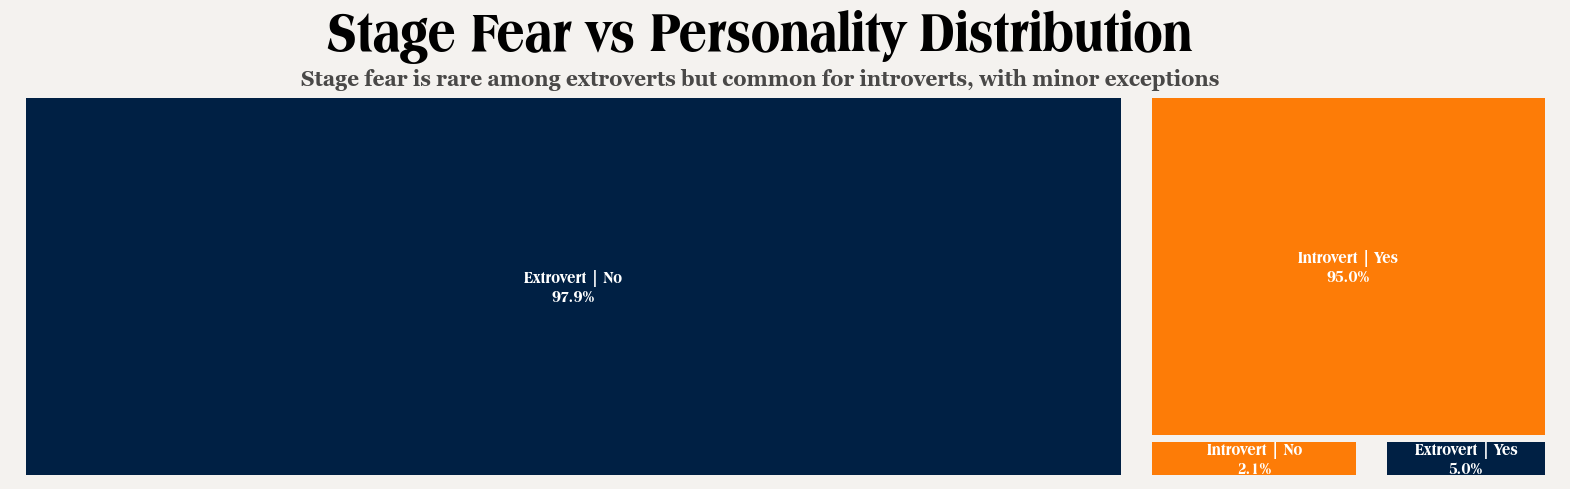

In [18]:
color_map = {'Extrovert': '#002044', 'Introvert': '#fd7c07'}
labels = [f"{row['Personality']} | {row['Stage_fear']}\n{row['Percentage']:.1f}%"for _, row in df_grouped.iterrows()]
sizes = df_grouped['Count']
colors = [color_map[p] for p in df_grouped['Personality']]
fig, ax = plt.subplots(figsize=(20, 5), facecolor=cols[2])
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=1, pad=True, text_kwargs={'fontsize':12, 'color':'white', 'weight':'bold','font':fonts[0]}, ax=ax)
ax.axis('off')
fig.suptitle("Stage Fear vs Personality Distribution",font=fonts[0],  fontsize=40, color='black', fontweight='bold', x=0.5, y=1.05,ha="center")
fig.text(0.5, 0.91,'Stage fear is rare among extroverts but common for introverts, with minor exceptions',
         font=fonts[1], fontsize=15, color="black", fontweight="bold", ha="center", va="center",alpha=0.7)
plt.show()


In [19]:
## social side-  stage fear, socail event attendence, dreained after socializing, friends circle size
# personal side- going out, post frequency,time spend alone
df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0,No,6,4,No,15,5,Extrovert
1,1,1,No,7,3,No,10,8,Extrovert
2,2,6,Yes,1,0,Yes,3,0,Introvert
3,3,3,No,7,3,No,11,5,Extrovert
4,4,1,No,4,4,No,13,6,Extrovert


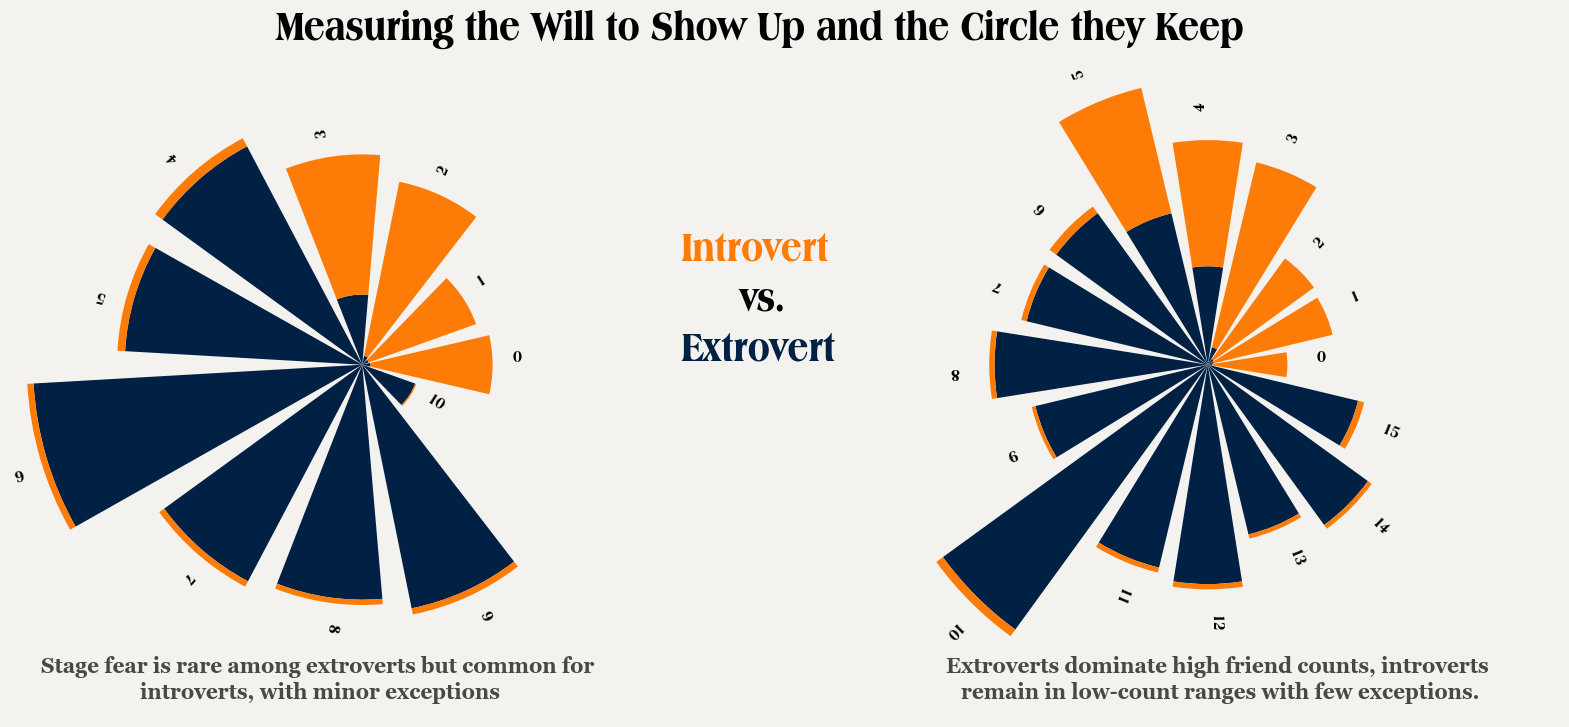

In [20]:
## --- First Data ---
data1 = df.groupby(["Social_event_attendance","Personality"]).size().reset_index(name="Count")
pivot_df1 = data1.pivot(index='Social_event_attendance', columns='Personality', values='Count').fillna(0)

# --- Second Data ---
data2 = df.groupby(["Friends_circle_size","Personality"]).size().reset_index(name="Count")
pivot_df2 = data2.pivot(index='Friends_circle_size', columns='Personality', values='Count').fillna(0)


# Setup subplot grid
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(20,10), facecolor=cols[2], dpi=100)
# fig.suptitle("Stage Fear vs Personality Distribution",font=fonts[0],  fontsize=40, color='black', fontweight='bold', x=0.5, y=1.05,ha="center")
# fig.text(0.5, 0.91,'Stage fear is rare among extroverts but common for introverts, with minor exceptions',
#          font=fonts[1], fontsize=15, color="black", fontweight="bold", ha="center", va="center",alpha=0.7)
# --- First chart ---
N1 = len(pivot_df1.index)
angles1 = np.linspace(0, 2*np.pi, N1, endpoint=False)
ax1 = axes[0]
ax1.set_facecolor(cols[2])

bottom = np.zeros(N1)
for j, col in enumerate(pivot_df1.columns):
    values = pivot_df1[col].values
    ax1.bar(angles1, values, width=2*np.pi/N1*0.8, bottom=bottom, color=cols[j], label=col)
    bottom += values

for i, attendance in enumerate(pivot_df1.index):
    total_height = pivot_df1.loc[attendance].sum()
    ax1.text(angles1[i], total_height+200, str(attendance), ha='center', va='bottom',
             fontname=fonts[0], color='black', fontsize=12, rotation=np.degrees(angles1[i]),
             rotation_mode='anchor')

ax1.set_yticks([])
ax1.set_xticks([])
ax1.spines['polar'].set_edgecolor(cols[2])
ax1.legend().remove()

# --- Second chart ---
N2 = len(pivot_df2.index)
angles2 = np.linspace(0, 2*np.pi, N2, endpoint=False)
ax2 = axes[1]
ax2.set_facecolor(cols[2])

bottom = np.zeros(N2)
for j, col in enumerate(pivot_df2.columns):
    values = pivot_df2[col].values
    ax2.bar(angles2, values, width=2*np.pi/N2*0.8, bottom=bottom, color=cols[j], label=col)
    bottom += values

for i, attendance in enumerate(pivot_df2.index):
    total_height = pivot_df2.loc[attendance].sum()
    ax2.text(angles2[i], total_height+200, str(attendance), ha='center', va='bottom',
             fontname=fonts[0], color='black', fontsize=12, rotation=np.degrees(angles2[i]),
             rotation_mode='anchor')

ax2.set_yticks([])
ax2.set_xticks([])
ax2.spines['polar'].set_edgecolor(cols[2])
ax2.legend().remove()

# --- Title for the whole figure ---
fig.text(0.5, 0.82, "Measuring the Will to Show Up and the Circle they Keep",
         ha='center', fontsize=30, weight='bold', color='black', font=fonts[0])
fig.text(0.28, 0.18,'Stage fear is rare among extroverts but common for \nintroverts, with minor exceptions',
         font=fonts[1], fontsize=15, color="black", fontweight="bold", ha="center", va="center",alpha=0.7)
fig.text(0.73, 0.18,'Extroverts dominate high friend counts, introverts \nremain in low-count ranges with few exceptions.',
         font=fonts[1], fontsize=15, color="black", fontweight="bold", ha="center", va="center",alpha=0.7)
fig.text(0.46,0.6,"Introvert",font= fonts[0],color=cols[1],fontsize=30,fontweight="bold")
fig.text(0.49,0.55,"vs.",font= fonts[0],color="black",fontsize=30,fontweight="bold")
fig.text(0.46,0.5,"Extrovert",font= fonts[0],color=cols[0],fontsize=30,fontweight="bold")
plt.show()

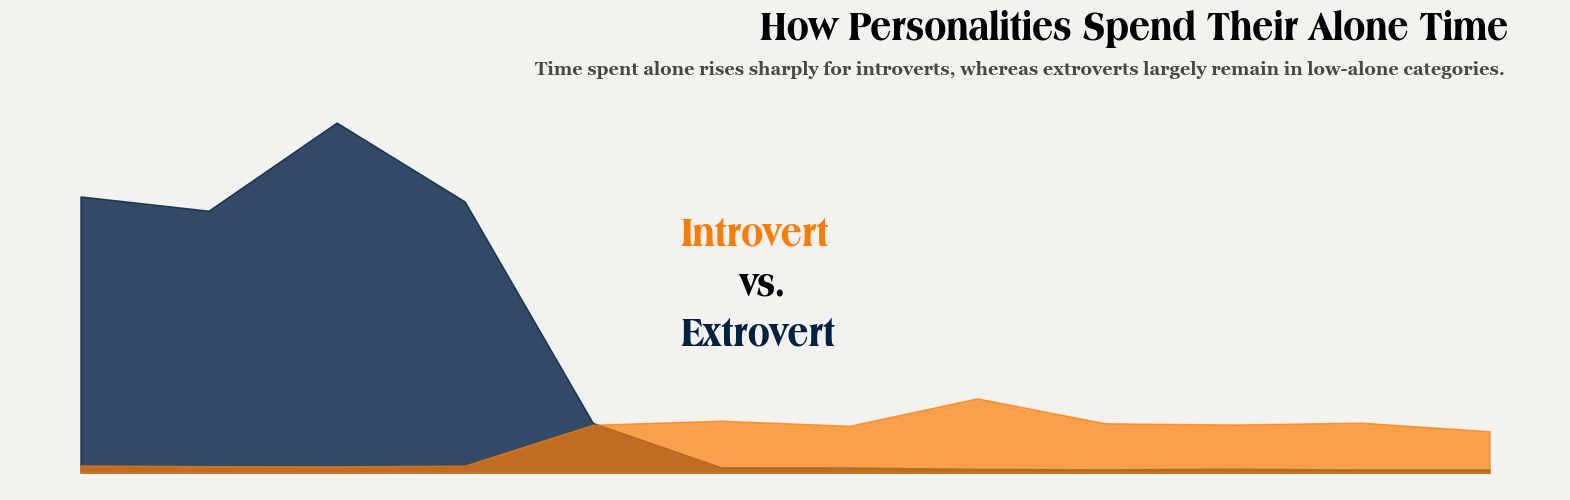

In [21]:
data = df.groupby(["Time_spent_Alone","Personality"]).size().reset_index(name="Count")
pivot_df = data.pivot(index="Time_spent_Alone", columns="Personality", values="Count").fillna(0)
fig, ax = plt.subplots(figsize=(20,5), facecolor=cols[2], dpi=100)
ax.fill_between(pivot_df.index, pivot_df["Extrovert"],color=cols[0], alpha=0.8, label="Extrovert")
ax.fill_between(pivot_df.index, pivot_df["Introvert"],color=cols[1], alpha=0.7, label="Introvert")
ax.set_xticks([]);ax.set_yticks([]);ax.set_facecolor(cols[2]);ax.set_xlabel("");ax.set_ylabel("")
fig.text(0.5, 1.01, "How Personalities Spend Their Alone Time",fontsize=30, weight="bold", color="black", fontname=fonts[0])
fig.text(0.63, 0.95,'Time spent alone rises sharply for introverts, whereas extroverts largely remain in low-alone categories.',
         font=fonts[1], fontsize=13, color="black", fontweight="bold", ha="center", va="center",alpha=0.7)
fig.text(0.46,0.6,"Introvert",font= fonts[0],color=cols[1],fontsize=30,fontweight="bold")
fig.text(0.49,0.5,"vs.",font= fonts[0],color="black",fontsize=30,fontweight="bold")
fig.text(0.46,0.4,"Extrovert",font= fonts[0],color=cols[0],fontsize=30,fontweight="bold")
for spine in ax.spines.values():
    spine.set_color(cols[2])
plt.show()


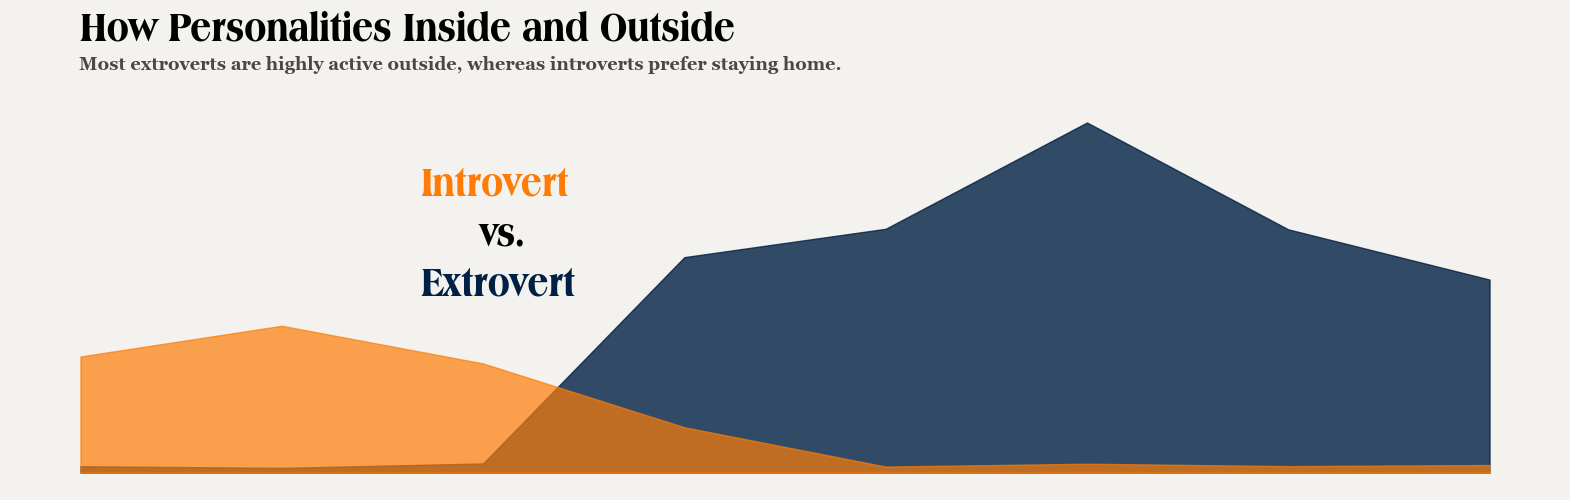

In [22]:
data = df.groupby(["Going_outside","Personality"]).size().reset_index(name="Count")
pivot_df = data.pivot(index="Going_outside", columns="Personality", values="Count").fillna(0)
fig, ax = plt.subplots(figsize=(20,5), facecolor=cols[2], dpi=100)
ax.fill_between(pivot_df.index, pivot_df["Extrovert"],color=cols[0], alpha=0.8, label="Extrovert")
ax.fill_between(pivot_df.index, pivot_df["Introvert"],color=cols[1], alpha=0.7, label="Introvert")
ax.set_xticks([]);ax.set_yticks([]);ax.set_facecolor(cols[2]);ax.set_xlabel("");ax.set_ylabel("")
fig.text(0.16, 1.01, "How Personalities Inside and Outside",fontsize=30, weight="bold", color="black", fontname=fonts[0])
fig.text(0.35, 0.96,'Most extroverts are highly active outside, whereas introverts prefer staying home.',
         font=fonts[1], fontsize=13, color="black", fontweight="bold", ha="center", va="center",alpha=0.7)
fig.text(0.33,0.7,"Introvert",font= fonts[0],color=cols[1],fontsize=30,fontweight="bold")
fig.text(0.36,0.6,"vs.",font= fonts[0],color="black",fontsize=30,fontweight="bold")
fig.text(0.33,0.5,"Extrovert",font= fonts[0],color=cols[0],fontsize=30,fontweight="bold")
for spine in ax.spines.values():
    spine.set_color(cols[2])
plt.show()


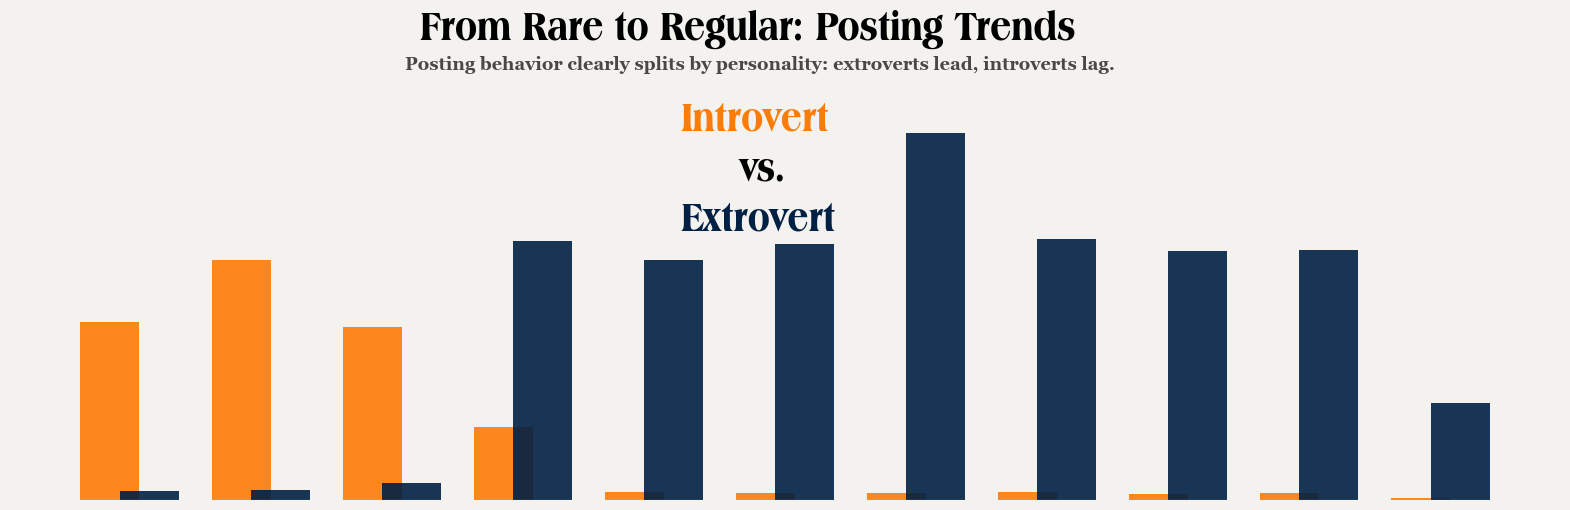

In [23]:
data = df.groupby(["Post_frequency","Personality"]).size().reset_index(name="Count")
pivot_df = data.pivot(index='Post_frequency', columns='Personality', values='Count')
col = {'Intro': '#fd7c07', 'Extro': '#002044'}
x = range(len(pivot_df))
fig, ax = plt.subplots(figsize=(20,5),facecolor=cols[2])
ax.patch.set_facecolor(cols[2])
ax.bar([pos - 0.15 for pos in x], pivot_df['Introvert'], width=0.45, color=col['Intro'],alpha=0.9)
ax.bar([pos + 0.15 for pos in x], pivot_df['Extrovert'], width=0.45, color=col['Extro'],alpha=0.9)
fig.text(0.33,1.03,"From Rare to Regular: Posting Trends", fontsize=30, weight="bold", color="black", fontname=fonts[0])
ax.set_xlabel('');ax.set_ylabel('');ax.set_yticks([]);ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_color(cols[2])
fig.text(0.5, 0.98,'Posting behavior clearly splits by personality: extroverts lead, introverts lag.',
         font=fonts[1], fontsize=13, color="black", fontweight="bold", ha="center", va="center",alpha=0.7)
fig.text(0.46,0.85,"Introvert",font= fonts[0],color=cols[1],fontsize=30,fontweight="bold")
fig.text(0.49,0.75,"vs.",font= fonts[0],color="black",fontsize=30,fontweight="bold")
fig.text(0.46,0.65,"Extrovert",font= fonts[0],color=cols[0],fontsize=30,fontweight="bold")
plt.show()

In [24]:
df['Personality'] = df['Personality'].map({'Extrovert': 1, 'Introvert': 0})
df["Stage_fear"] = df["Stage_fear"].map({"Yes": True, "No": False})
df["Drained_after_socializing"] = df["Drained_after_socializing"].map({"Yes": True, "No": False})
df["Social_Score"] = (
    df["Social_event_attendance"] +
    df["Going_outside"] +
    df["Friends_circle_size"])

In [25]:
num_cols = ["Time_spent_Alone", "Social_event_attendance", "Going_outside", 
            "Friends_circle_size", "Post_frequency"]
cat_cols = ["Stage_fear", "Drained_after_socializing"]

# Numeric columns: fill with median
for col in num_cols:
    test_df[col].fillna(test_df[col].median(), inplace=True)

# Categorical columns: fill with mode
for col in cat_cols:
    test_df[col].fillna(test_df[col].mode()[0], inplace=True)

# Check remaining nulls
print(test_df.isna().sum())


id                           0
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
dtype: int64


In [26]:
# Map categorical columns
test_df["Stage_fear"] = test_df["Stage_fear"].map({"Yes": True, "No": False})
test_df["Drained_after_socializing"] = test_df["Drained_after_socializing"].map({"Yes": True, "No": False})

# Create Social_Score
test_df["Social_Score"] = (
    test_df["Social_event_attendance"] +
    test_df["Going_outside"] +
    test_df["Friends_circle_size"]
)


In [27]:
X_train = df.drop(columns=['Personality', 'id'])
y_train = df['Personality']

In [28]:
X_test = test_df.drop(columns=['id'])
test_ID = test_df['id']

In [29]:
# X = df.drop(["id", "Personality"], axis=1)
# y = df["Personality"]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

gb_best = GradientBoostingClassifier(learning_rate=0.01, n_estimators=100, random_state=42)
gb_best.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.01, random_state=42)

In [32]:
test_preds = gb_best.predict(X_test)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Split training data for evaluation
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Train on training split
gb_best.fit(X_tr, y_tr)

# Predict on validation split
y_val_pred = gb_best.predict(X_val)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))


Accuracy: 0.97165991902834
Precision: 0.9755747126436781
Recall: 0.9865601162368326
F1 Score: 0.9810366624525917


In [34]:
# Prepare test features
X_test = test_df.drop(columns=['id'])
test_ID = test_df['id']

# Predict classes
test_preds = gb_best.predict(X_test)

# Map to labels
submission = pd.DataFrame({
    'id': test_ID,
    'Personality': pd.Series(test_preds).map({1: 'Extrovert', 0: 'Introvert'})
})

# Save CSV
submission.to_csv('submission.csv', index=False)
submission.head()
print("Submission created successfully")


Submission created successfully
